# Part 1: Data Acquisition & Preparation

## Step 1.1: Environment Setup & Downloading the Raw Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import io

# URL for the 60-minute resolution dataset (Open Power System Data)
url = "https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"

# Download the file (this file is large, ~100MB+, so this may take a minute)
print("Downloading data... this may take a minute or two.")
response = requests.get(url)
response.raise_for_status()  # will error out clearly if download fails

# Load into pandas directly from the downloaded bytes
raw_df = pd.read_csv(io.BytesIO(response.content), low_memory=False)

print("Download complete.")
print("Shape:", raw_df.shape)

print("\nColumn names containing 'DE':")
de_cols = [col for col in raw_df.columns if 'DE' in col]
print(de_cols)

print("\nFirst few rows of the timestamp column:")
print(raw_df[['utc_timestamp']].head())
print(raw_df[['utc_timestamp']].tail())

Download complete.
Shape: (50401, 300)

Column names containing 'DE':
['DE_load_actual_entsoe_transparency', 'DE_load_forecast_entsoe_transparency', 'DE_solar_capacity', 'DE_solar_generation_actual', 'DE_solar_profile', 'DE_wind_capacity', 'DE_wind_generation_actual', 'DE_wind_profile', 'DE_wind_offshore_capacity', 'DE_wind_offshore_generation_actual', 'DE_wind_offshore_profile', 'DE_wind_onshore_capacity', 'DE_wind_onshore_generation_actual', 'DE_wind_onshore_profile', 'DE_50hertz_load_actual_entsoe_transparency', 'DE_50hertz_load_forecast_entsoe_transparency', 'DE_50hertz_solar_generation_actual', 'DE_50hertz_wind_generation_actual', 'DE_50hertz_wind_offshore_generation_actual', 'DE_50hertz_wind_onshore_generation_actual', 'DE_LU_load_actual_entsoe_transparency', 'DE_LU_load_forecast_entsoe_transparency', 'DE_LU_price_day_ahead', 'DE_LU_solar_generation_actual', 'DE_LU_wind_generation_actual', 'DE_LU_wind_offshore_generation_actual', 'DE_LU_wind_onshore_generation_actual', 'DE_amprio

## Step 1.2: Selecting Columns, Parsing Timestamps & Slicing the Date Range

In [2]:
# Convert timestamp column to proper datetime
raw_df['utc_timestamp'] = pd.to_datetime(raw_df['utc_timestamp'])

# Select only the columns we need for now: timestamp + DE load + DE_LU load (fallback)
cols_needed = ['utc_timestamp', 'DE_load_actual_entsoe_transparency', 'DE_LU_load_actual_entsoe_transparency']
df = raw_df[cols_needed].copy()

# Set timestamp as index
df = df.set_index('utc_timestamp')

# Check how many missing values exist in each column, and where the DE column's NaNs start
print("Missing values in DE_load column:", df['DE_load_actual_entsoe_transparency'].isna().sum())
print("Missing values in DE_LU_load column:", df['DE_LU_load_actual_entsoe_transparency'].isna().sum())

first_de_nan = df[df['DE_load_actual_entsoe_transparency'].isna()].index.min()
print("\nFirst NaN timestamp in DE_load column:", first_de_nan)

# Combine: use DE_load where available, fall back to DE_LU_load where DE_load is missing
df['load_combined'] = df['DE_load_actual_entsoe_transparency'].combine_first(
    df['DE_LU_load_actual_entsoe_transparency']
)

print("\nMissing values in combined load column after merge:", df['load_combined'].isna().sum())

# Slice to required date range: 1 Jan 2015 to end of file
df = df.loc['2015-01-01':]

print("\nFinal date range:", df.index.min(), "to", df.index.max())
print("Final shape:", df.shape)
print("\nRemaining missing values in combined load column:", df['load_combined'].isna().sum())

# Preview
df[['load_combined']].head()

Missing values in DE_load column: 1
Missing values in DE_LU_load column: 32877

First NaN timestamp in DE_load column: 2014-12-31 23:00:00+00:00

Missing values in combined load column after merge: 1

Final date range: 2015-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00
Final shape: (50400, 3)

Remaining missing values in combined load column: 0


,load_combined
utc_timestamp,
2015-01-01 00:00:00+00:00,41151.0
2015-01-01 01:00:00+00:00,40135.0
2015-01-01 02:00:00+00:00,39106.0
2015-01-01 03:00:00+00:00,38765.0
2015-01-01 04:00:00+00:00,38941.0


## Step 1.3: Resampling to Daily and Weekly Frequency

In [3]:
# Keep a clean hourly series (used later for the LSTM in Part 6)
hourly = df[['load_combined']].rename(columns={'load_combined': 'load'})

# Resample to daily (sum of the 24 hourly values = total daily load)
daily = hourly.resample('D').sum()

# Resample to weekly (using week starting Monday, standard ISO convention)
weekly = hourly.resample('W-MON').sum()

print("Hourly shape:", hourly.shape, "| range:", hourly.index.min(), "to", hourly.index.max())
print("Daily shape:", daily.shape, "| range:", daily.index.min(), "to", daily.index.max())
print("Weekly shape:", weekly.shape, "| range:", weekly.index.min(), "to", weekly.index.max())

# Sanity check: any zero or suspiciously low values (would indicate resampling issues)
print("\nDaily - any zero values?", (daily['load'] == 0).sum())
print("Weekly - any zero values?", (weekly['load'] == 0).sum())

# Check first/last weekly rows (edges can be partial weeks - worth inspecting)
print("\nFirst 2 weekly rows:")
print(weekly.head(2))
print("\nLast 2 weekly rows:")
print(weekly.tail(2))

Hourly shape: (50400, 1) | range: 2015-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00
Daily shape: (2100, 1) | range: 2015-01-01 00:00:00+00:00 to 2020-09-30 00:00:00+00:00
Weekly shape: (301, 1) | range: 2015-01-05 00:00:00+00:00 to 2020-10-05 00:00:00+00:00

Daily - any zero values? 0
Weekly - any zero values? 0

First 2 weekly rows:
                                load
utc_timestamp                       
2015-01-05 00:00:00+00:00  5860359.0
2015-01-12 00:00:00+00:00  9600112.0

Last 2 weekly rows:
                                load
utc_timestamp                       
2020-09-28 00:00:00+00:00  9019632.0
2020-10-05 00:00:00+00:00  2774807.0


## Step 1.4: Trimming Partial Edge Weeks

In [4]:
# Confirm the day-count in each edge week before trimming (sanity check)
first_week_start = hourly.index.min()
last_week_end = hourly.index.max()
print("Hourly data starts:", first_week_start, "| ends:", last_week_end)

# Drop first and last row of weekly (confirmed partial above)
weekly_trimmed = weekly.iloc[1:-1].copy()

print("\nWeekly shape before trim:", weekly.shape)
print("Weekly shape after trim:", weekly_trimmed.shape)
print("\nNew weekly range:", weekly_trimmed.index.min(), "to", weekly_trimmed.index.max())

print("\nFirst 2 rows after trim:")
print(weekly_trimmed.head(2))
print("\nLast 2 rows after trim:")
print(weekly_trimmed.tail(2))

# Similarly check daily edges - daily is less likely to have partial-day issues
# since hourly data starts/ends exactly on hour boundaries, but let's confirm counts per day
daily_hour_counts = hourly.resample('D').count()
print("\nAny days with fewer than 24 hourly readings?")
print(daily_hour_counts[daily_hour_counts['load'] < 24])

# Overwrite weekly with trimmed version going forward
weekly = weekly_trimmed

Hourly data starts: 2015-01-01 00:00:00+00:00 | ends: 2020-09-30 23:00:00+00:00

Weekly shape before trim: (301, 1)
Weekly shape after trim: (299, 1)

New weekly range: 2015-01-12 00:00:00+00:00 to 2020-09-28 00:00:00+00:00

First 2 rows after trim:
                                load
utc_timestamp                       
2015-01-12 00:00:00+00:00  9600112.0
2015-01-19 00:00:00+00:00  9660382.0

Last 2 rows after trim:
                                load
utc_timestamp                       
2020-09-21 00:00:00+00:00  8786893.0
2020-09-28 00:00:00+00:00  9019632.0

Any days with fewer than 24 hourly readings?
Empty DataFrame
Columns: [load]
Index: []


## Step 1.5: Initial EDA Plots (Hourly, Daily, Weekly)

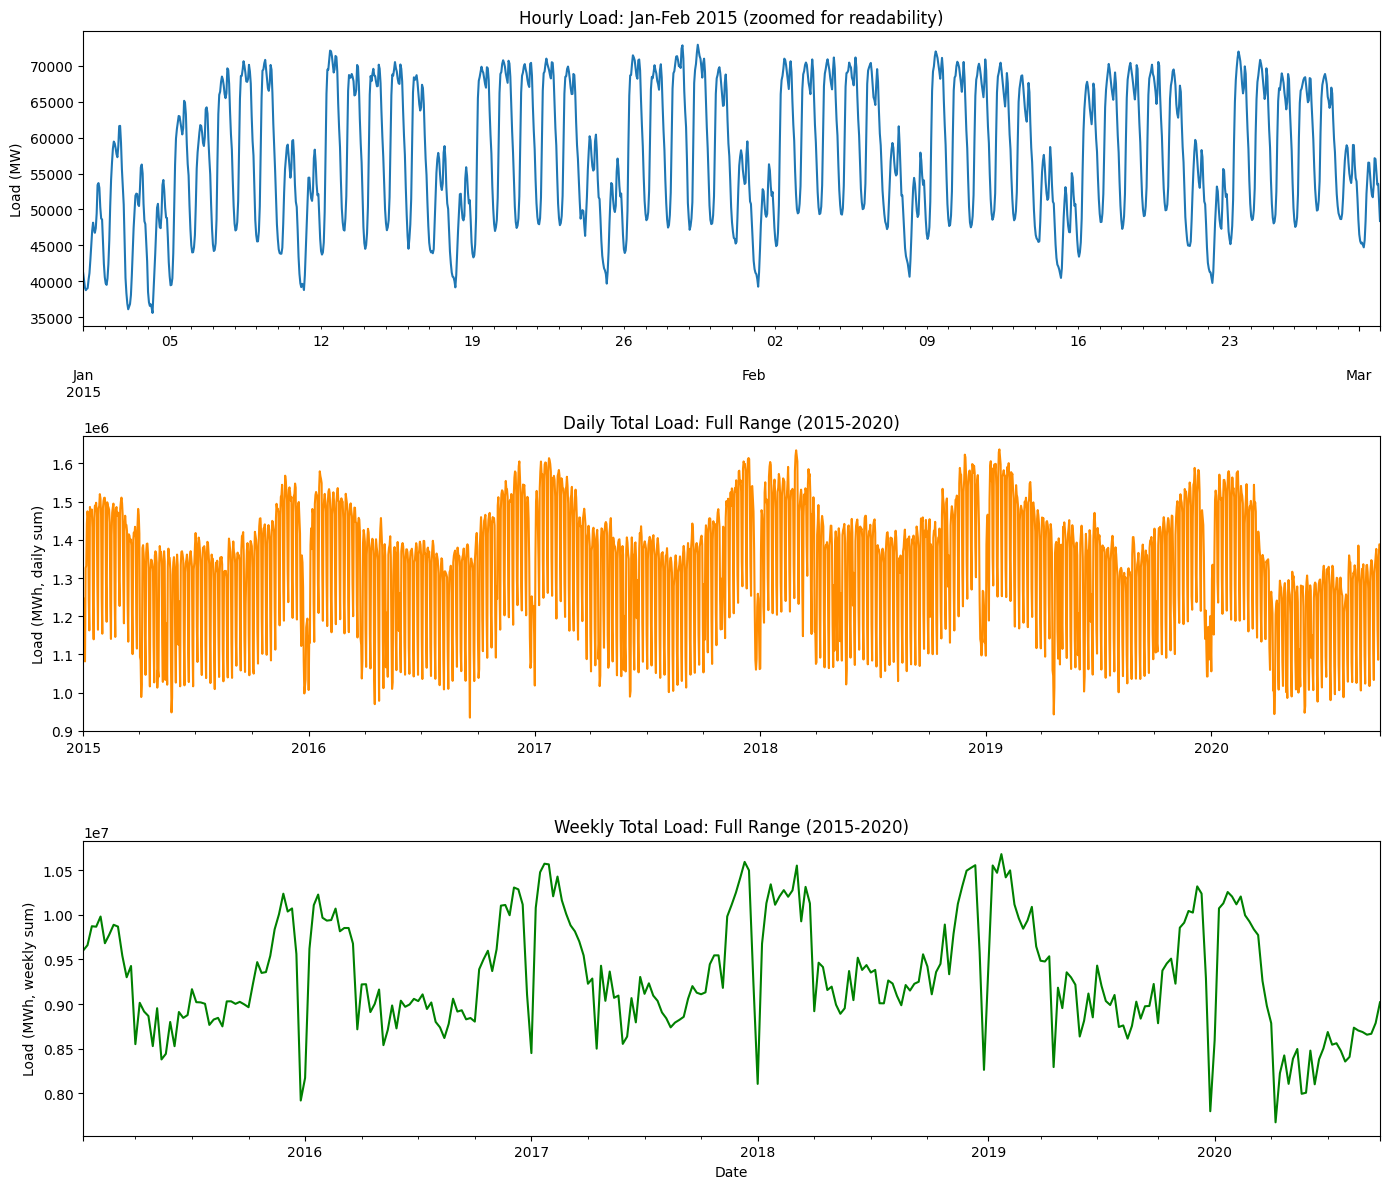

Weekly load descriptive statistics:
count    2.990000e+02
mean     9.325034e+06
std      6.291399e+05
min      7.673833e+06
25%      8.883780e+06
50%      9.224888e+06
75%      9.861912e+06
max      1.068140e+07
Name: load, dtype: float64


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Hourly plot (zoomed to first 2 months to avoid an unreadable smear)
hourly.loc['2015-01-01':'2015-03-01'].plot(ax=axes[0], legend=False)
axes[0].set_title('Hourly Load: Jan-Feb 2015 (zoomed for readability)')
axes[0].set_ylabel('Load (MW)')
axes[0].set_xlabel('')

# Daily plot (full range)
daily.plot(ax=axes[1], legend=False, color='darkorange')
axes[1].set_title('Daily Total Load: Full Range (2015-2020)')
axes[1].set_ylabel('Load (MWh, daily sum)')
axes[1].set_xlabel('')

# Weekly plot (full range) - our main series for Parts 2-5
weekly.plot(ax=axes[2], legend=False, color='green')
axes[2].set_title('Weekly Total Load: Full Range (2015-2020)')
axes[2].set_ylabel('Load (MWh, weekly sum)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.style.use('ggplot')
plt.savefig('eda_multi_resolution.png', dpi=150)
plt.show()

# Quick descriptive statistics on the weekly series (our primary modelling series)
print("Weekly load descriptive statistics:")
print(weekly['load'].describe())

## Step 1.6: Seasonal Decomposition (Trend / Seasonal / Residual)

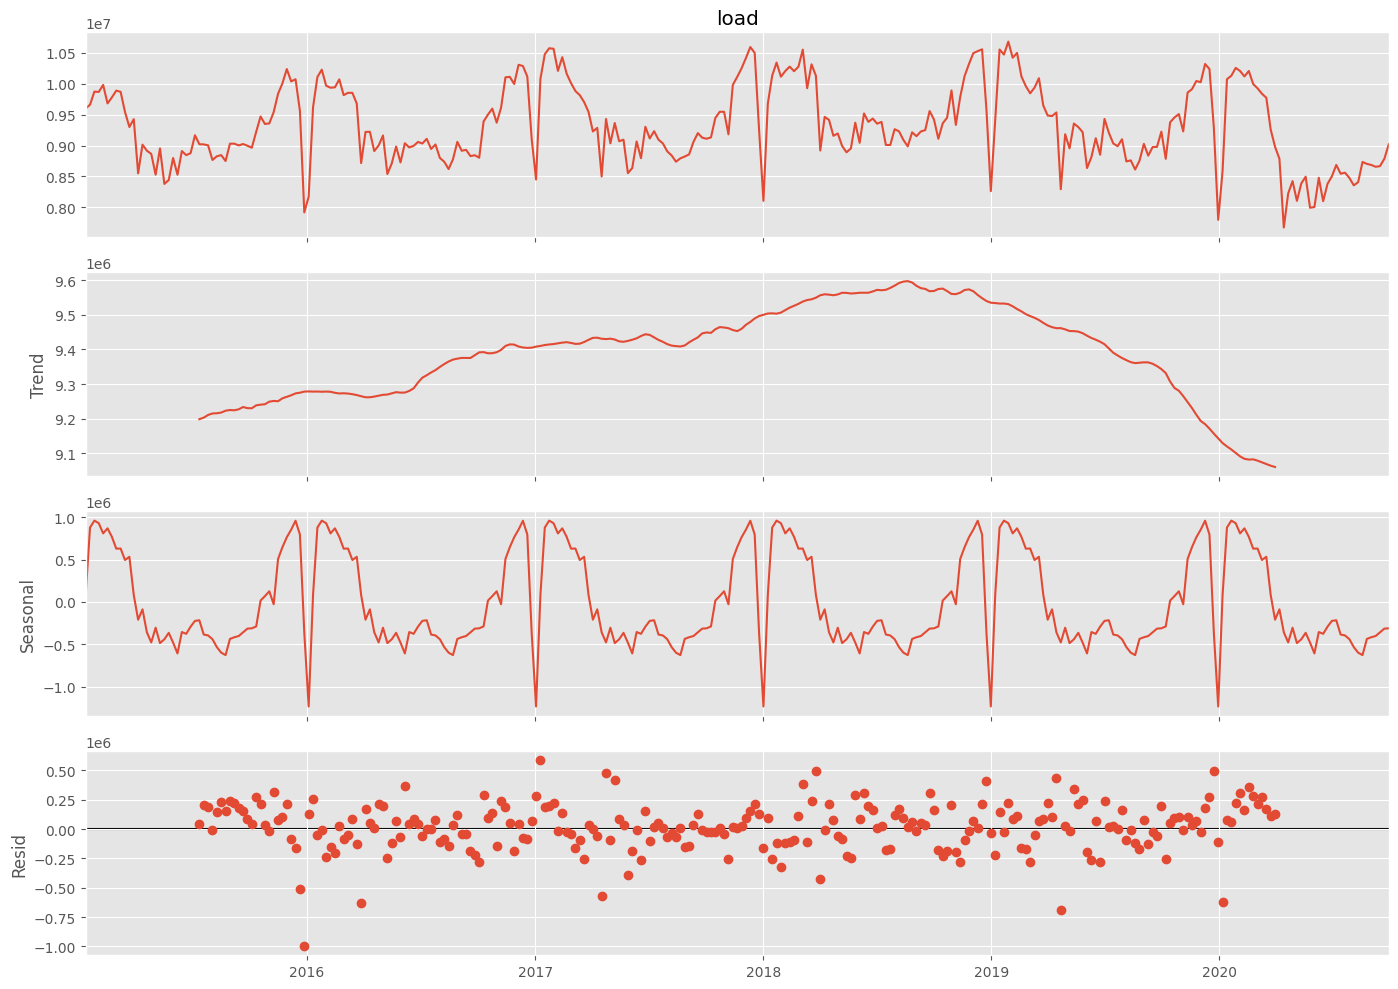

Seasonal strength: 0.880
Trend strength: 0.504

(Values closer to 1 indicate a stronger, more dominant component)


In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Additive decomposition, period=52 (weeks per year)
decomposition = seasonal_decompose(weekly['load'], model='additive', period=52)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.style.use('ggplot')
plt.savefig('seasonal_decomposition_weekly.png', dpi=150)
plt.show()

# Quantify the relative strength of trend and seasonality vs residual
# (a simple variance-based measure commonly used to describe decomposition strength)
resid = decomposition.resid.dropna()
detrended = (weekly['load'] - decomposition.trend).dropna()
deseasonalized = (weekly['load'] - decomposition.seasonal).dropna()

seasonal_strength = max(0, 1 - resid.var() / detrended.var())
trend_strength = max(0, 1 - resid.var() / deseasonalized.var())

print(f"Seasonal strength: {seasonal_strength:.3f}")
print(f"Trend strength: {trend_strength:.3f}")
print("\n(Values closer to 1 indicate a stronger, more dominant component)")

## Step 1.7: Stationarity Testing (ADF, ACF, PACF, Differencing)


--- ADF Test: Raw Weekly Load ---
ADF Statistic: -5.0179
p-value: 0.0000
Critical Values: {'1%': np.float64(-3.452636878592149), '5%': np.float64(-2.8713543954331433), '10%': np.float64(-2.5719993576515705)}
>> Result: Stationary (reject H0 at 5%)

--- ADF Test: First-Order Differenced (d=1) ---
ADF Statistic: -10.7985
p-value: 0.0000
Critical Values: {'1%': np.float64(-3.452867117291862), '5%': np.float64(-2.8714554160827745), '10%': np.float64(-2.5720532321867466)}
>> Result: Stationary (reject H0 at 5%)

--- ADF Test: Seasonally Differenced (D=1, period=52) ---
ADF Statistic: -2.3801
p-value: 0.1474
Critical Values: {'1%': np.float64(-3.458128284586202), '5%': np.float64(-2.873761835239286), '10%': np.float64(-2.5732834559706235)}
>> Result: Non-stationary (fail to reject H0 at 5%)

--- ADF Test: First + Seasonal Differenced (d=1, D=1) ---
ADF Statistic: -8.5018
p-value: 0.0000
Critical Values: {'1%': np.float64(-3.458128284586202), '5%': np.float64(-2.873761835239286), '10%': np.f

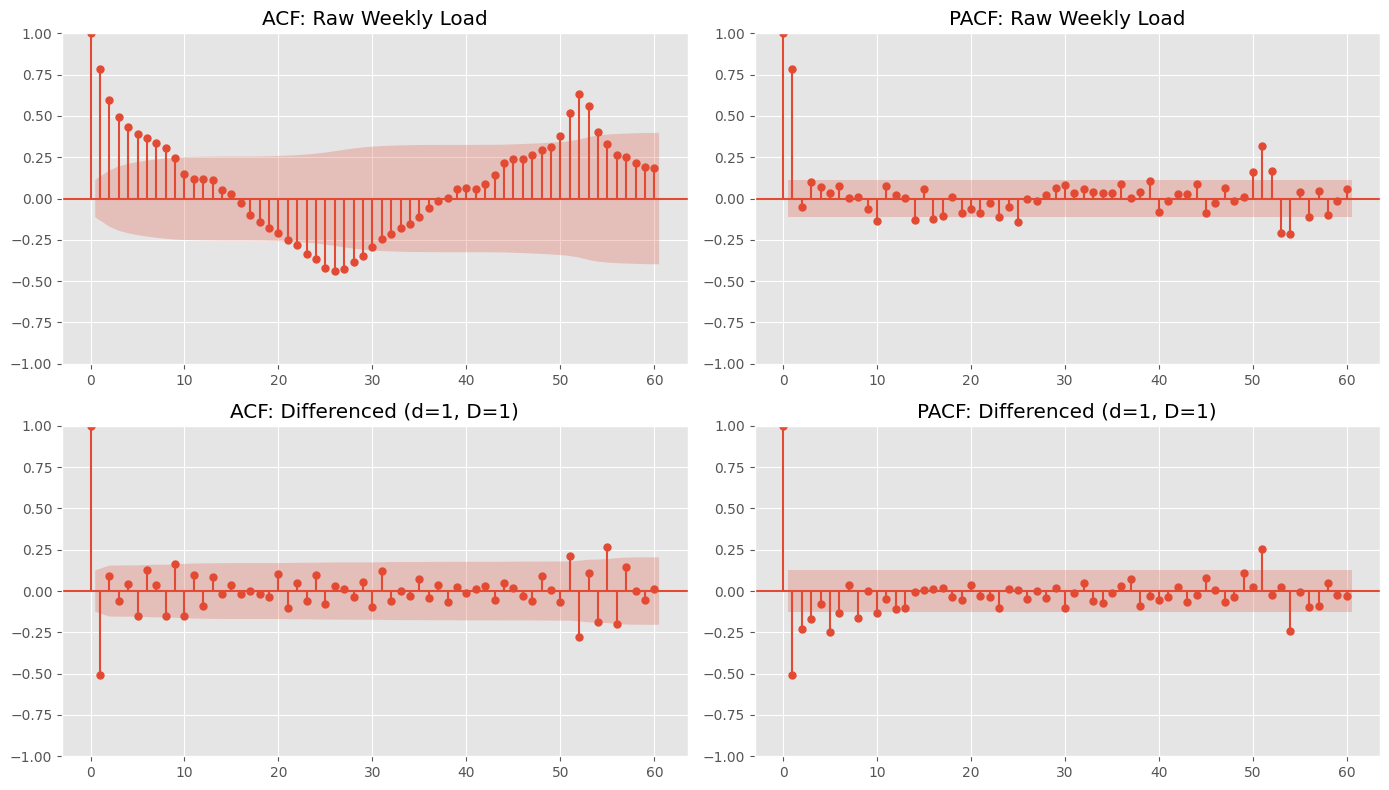

In [7]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def run_adf(series, label):
    result = adfuller(series.dropna())
    print(f"\n--- ADF Test: {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values: {result[4]}")
    if result[1] < 0.05:
        print(">> Result: Stationary (reject H0 at 5%)")
    else:
        print(">> Result: Non-stationary (fail to reject H0 at 5%)")

# 1. Test the raw weekly series
run_adf(weekly['load'], "Raw Weekly Load")

# 2. First-order differencing
weekly_diff1 = weekly['load'].diff().dropna()
run_adf(weekly_diff1, "First-Order Differenced (d=1)")

# 3. Seasonal differencing (lag 52)
weekly_seasonal_diff = weekly['load'].diff(52).dropna()
run_adf(weekly_seasonal_diff, "Seasonally Differenced (D=1, period=52)")

# 4. Both: first difference + seasonal difference
weekly_diff1_seasonal = weekly['load'].diff().diff(52).dropna()
run_adf(weekly_diff1_seasonal, "First + Seasonal Differenced (d=1, D=1)")

# ACF/PACF plots - raw series and the differenced version that achieved stationarity
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(weekly['load'], lags=60, ax=axes[0, 0])
axes[0, 0].set_title('ACF: Raw Weekly Load')

plot_pacf(weekly['load'], lags=60, ax=axes[0, 1])
axes[0, 1].set_title('PACF: Raw Weekly Load')

plot_acf(weekly_diff1_seasonal, lags=60, ax=axes[1, 0])
axes[1, 0].set_title('ACF: Differenced (d=1, D=1)')

plot_pacf(weekly_diff1_seasonal, lags=60, ax=axes[1, 1])
axes[1, 1].set_title('PACF: Differenced (d=1, D=1)')

# Option B: use a matplotlib style globally, before plotting
plt.style.use('ggplot')
plt.tight_layout()
plt.savefig('stationarity_acf_pacf.png', dpi=150)
plt.show()

# Part 2: Benchmark Models

## Step 2.1: Train/Test Split + Mean, Naive, Seasonal Naive, and Drift Forecasts

Train shape: (195, 1) | range: 2015-01-12 00:00:00+00:00 to 2018-10-01 00:00:00+00:00
Test shape: (104, 1) | range: 2018-10-08 00:00:00+00:00 to 2020-09-28 00:00:00+00:00


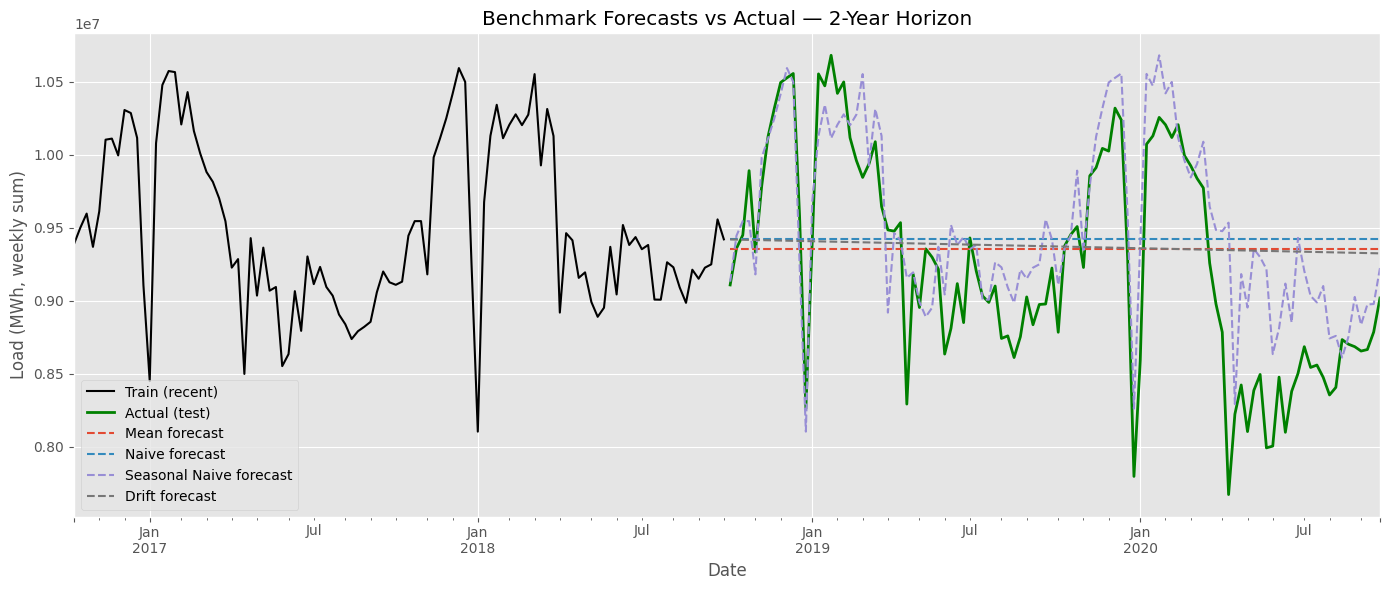


Mean forecast value (constant): 9358180.748717949
Naive forecast value (constant): 9421232.0
Drift slope per week: -922.0618556701031


In [8]:
# 2-year forecast horizon = 104 weeks
horizon = 104

train = weekly.iloc[:-horizon].copy()
test = weekly.iloc[-horizon:].copy()

print("Train shape:", train.shape, "| range:", train.index.min(), "to", train.index.max())
print("Test shape:", test.shape, "| range:", test.index.min(), "to", test.index.max())

# --- Benchmark 1: Mean forecast ---
mean_forecast = pd.Series(train['load'].mean(), index=test.index)

# --- Benchmark 2: Naive forecast (last observed value repeated) ---
naive_forecast = pd.Series(train['load'].iloc[-1], index=test.index)

# --- Benchmark 3: Seasonal Naive forecast (value from 52 weeks earlier, cycled) ---
# For each test week, use the value from exactly 52 weeks before it in the full series
seasonal_naive_forecast = weekly['load'].shift(52).loc[test.index]

# --- Benchmark 4: Drift forecast (extrapolate line from first to last training point) ---
n_train = len(train)
first_val = train['load'].iloc[0]
last_val = train['load'].iloc[-1]
drift_slope = (last_val - first_val) / (n_train - 1)
drift_forecast = pd.Series(
    [last_val + drift_slope * (h + 1) for h in range(horizon)],
    index=test.index
)

# Plot all benchmarks against actual test data
fig, ax = plt.subplots(figsize=(14, 6))
train['load'].tail(104).plot(ax=ax, label='Train (recent)', color='black')
test['load'].plot(ax=ax, label='Actual (test)', color='green', linewidth=2)
mean_forecast.plot(ax=ax, label='Mean forecast', linestyle='--')
naive_forecast.plot(ax=ax, label='Naive forecast', linestyle='--')
seasonal_naive_forecast.plot(ax=ax, label='Seasonal Naive forecast', linestyle='--')
drift_forecast.plot(ax=ax, label='Drift forecast', linestyle='--')

ax.set_title('Benchmark Forecasts vs Actual — 2-Year Horizon')
ax.set_ylabel('Load (MWh, weekly sum)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.savefig('benchmark_forecasts.png', dpi=150)
plt.show()

print("\nMean forecast value (constant):", mean_forecast.iloc[0])
print("Naive forecast value (constant):", naive_forecast.iloc[0])
print("Drift slope per week:", drift_slope)

## Step 2.2: Evaluation Metrics for the Benchmarks (RMSE, MAE, MAPE)

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
def evaluate_forecast(actual, forecast, name):
    # Align indices in case of any mismatch
    actual_aligned, forecast_aligned = actual.align(forecast, join='inner')
    rmse = np.sqrt(mean_squared_error(actual_aligned, forecast_aligned))
    mae = mean_absolute_error(actual_aligned, forecast_aligned)
    mape = np.mean(np.abs((actual_aligned - forecast_aligned) / actual_aligned)) * 100
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape}

results = []
results.append(evaluate_forecast(test['load'], mean_forecast, 'Mean'))
results.append(evaluate_forecast(test['load'], naive_forecast, 'Naive'))
results.append(evaluate_forecast(test['load'], seasonal_naive_forecast, 'Seasonal Naive'))
results.append(evaluate_forecast(test['load'], drift_forecast, 'Drift'))

# Build master metrics table - we will append to this dataframe as we build more models
metrics_table = pd.DataFrame(results)
metrics_table = metrics_table.sort_values('RMSE').reset_index(drop=True)

print("Benchmark Model Evaluation Metrics:")
print(metrics_table.to_string(index=False))

# Save so we can keep appending to it in later parts
metrics_table.to_csv('metrics_table.csv', index=False)

Benchmark Model Evaluation Metrics:
         Model          RMSE           MAE  MAPE (%)
Seasonal Naive 454051.060112 342863.826923  3.862459
         Drift 727256.958348 620585.440028  6.817314
          Mean 739221.517876 629533.841174  6.906660
         Naive 749960.658994 640566.778846  7.071051


# Part 3: SARIMA Model

## Step 3.1: Grid Search over (p,d,q)(P,D,Q) Using AIC

In [10]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import time

warnings.filterwarnings("ignore")  # suppress convergence warnings during grid search

# Non-seasonal orders per the brief's required range
p_range = range(0, 7)   # 0 to 6 inclusive
d_range = range(0, 3)   # 0 to 2 inclusive
q_range = range(0, 7)   # 0 to 6 inclusive

# Seasonal orders - informed by Part 1 (D=1 needed, s=52); P,Q kept small for tractability
P_range = range(0, 2)
D_fixed = [1]
Q_range = range(0, 2)
s = 52

all_combinations = list(itertools.product(p_range, d_range, q_range, P_range, D_fixed, Q_range))
print(f"Total combinations to test: {len(all_combinations)}")

results_list = []
start_time = time.time()

for i, (p, d, q, P, D, Q) in enumerate(all_combinations):
    try:
        model = SARIMAX(
            train['load'],
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fitted = model.fit(disp=False)
        results_list.append({
            'p': p, 'd': d, 'q': q, 'P': P, 'D': D, 'Q': Q, 's': s,
            'AIC': fitted.aic
        })
    except Exception as e:
        continue  # skip combinations that fail to converge

    if (i + 1) % 50 == 0:
        elapsed = time.time() - start_time
        print(f"Tested {i+1}/{len(all_combinations)} combinations... ({elapsed:.1f}s elapsed)")

print(f"\nGrid search complete. Total time: {(time.time()-start_time)/60:.1f} minutes")
print(f"Successful fits: {len(results_list)} / {len(all_combinations)}")

# Build results dataframe, sort by AIC
sarima_results = pd.DataFrame(results_list).sort_values('AIC').reset_index(drop=True)

print("\nTop 10 models by AIC:")
print(sarima_results.head(10).to_string(index=False))

# Save for reference
sarima_results.to_csv('sarima_grid_search_results.csv', index=False)

Total combinations to test: 588
Tested 50/588 combinations... (492.7s elapsed)
Tested 100/588 combinations... (1914.2s elapsed)
Tested 150/588 combinations... (2994.8s elapsed)
Tested 200/588 combinations... (5289.4s elapsed)
Tested 250/588 combinations... (7059.9s elapsed)
Tested 300/588 combinations... (9090.5s elapsed)
Tested 350/588 combinations... (11343.5s elapsed)
Tested 400/588 combinations... (13709.2s elapsed)
Tested 450/588 combinations... (16837.7s elapsed)
Tested 500/588 combinations... (19406.3s elapsed)
Tested 550/588 combinations... (21905.8s elapsed)

Grid search complete. Total time: 408.5 minutes
Successful fits: 588 / 588

Top 10 models by AIC:
 p  d  q  P  D  Q  s         AIC
 3  2  6  1  1  1 52 2315.365030
 2  2  6  1  1  1 52 2316.039476
 3  2  6  0  1  1 52 2316.313090
 4  2  6  1  1  1 52 2317.651130
 4  2  6  0  1  1 52 2318.557297
 5  2  6  1  1  1 52 2319.064824
 1  2  6  1  1  1 52 2321.226229
 0  2  6  1  1  1 52 2322.045268
 0  2  6  0  1  1 52 2323.0476

## Step 3.2: Compare AIC-Best Model vs. a d=1-Constrained Model, Then Fit Both

In [11]:
# Overall AIC-best (from grid search)
best_overall = sarima_results.iloc[0]
print("=== AIC-Best Model (unconstrained) ===")
print(best_overall)

# Best model restricted to d=1 (consistent with Part 1 ADF findings)
d1_results = sarima_results[sarima_results['d'] == 1].sort_values('AIC')
best_d1 = d1_results.iloc[0]
print("\n=== Best Model with d=1 (consistent with Part 1 stationarity testing) ===")
print(best_d1)

print(f"\nAIC difference: {best_d1['AIC'] - best_overall['AIC']:.2f}")

# Fit both models fully on the training data
model_aic_best = SARIMAX(
    train['load'],
    order=(int(best_overall['p']), int(best_overall['d']), int(best_overall['q'])),
    seasonal_order=(int(best_overall['P']), int(best_overall['D']), int(best_overall['Q']), 52),
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

model_d1_best = SARIMAX(
    train['load'],
    order=(int(best_d1['p']), int(best_d1['d']), int(best_d1['q'])),
    seasonal_order=(int(best_d1['P']), int(best_d1['D']), int(best_d1['Q']), 52),
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

print("\n\n========== AIC-BEST MODEL SUMMARY ==========")
print(model_aic_best.summary())

print("\n\n========== d=1 MODEL SUMMARY ==========")
print(model_d1_best.summary())

=== AIC-Best Model (unconstrained) ===
p         3.00000
d         2.00000
q         6.00000
P         1.00000
D         1.00000
Q         1.00000
s        52.00000
AIC    2315.36503
Name: 0, dtype: float64

=== Best Model with d=1 (consistent with Part 1 stationarity testing) ===
p         4.000000
d         1.000000
q         6.000000
P         1.000000
D         1.000000
Q         1.000000
s        52.000000
AIC    2327.613677
Name: 11, dtype: float64

AIC difference: 12.25


========== AIC-BEST MODEL SUMMARY ==========
                                      SARIMAX Results                                       
Dep. Variable:                                 load   No. Observations:                  195
Model:             SARIMAX(3, 2, 6)x(1, 1, [1], 52)   Log Likelihood               -1145.683
Date:                              Sun, 12 Jul 2026   AIC                           2315.365
Time:                                      16:05:45   BIC                           2344.246
Sample

## Step 3.3: Residual Diagnostics for Both Candidate Models

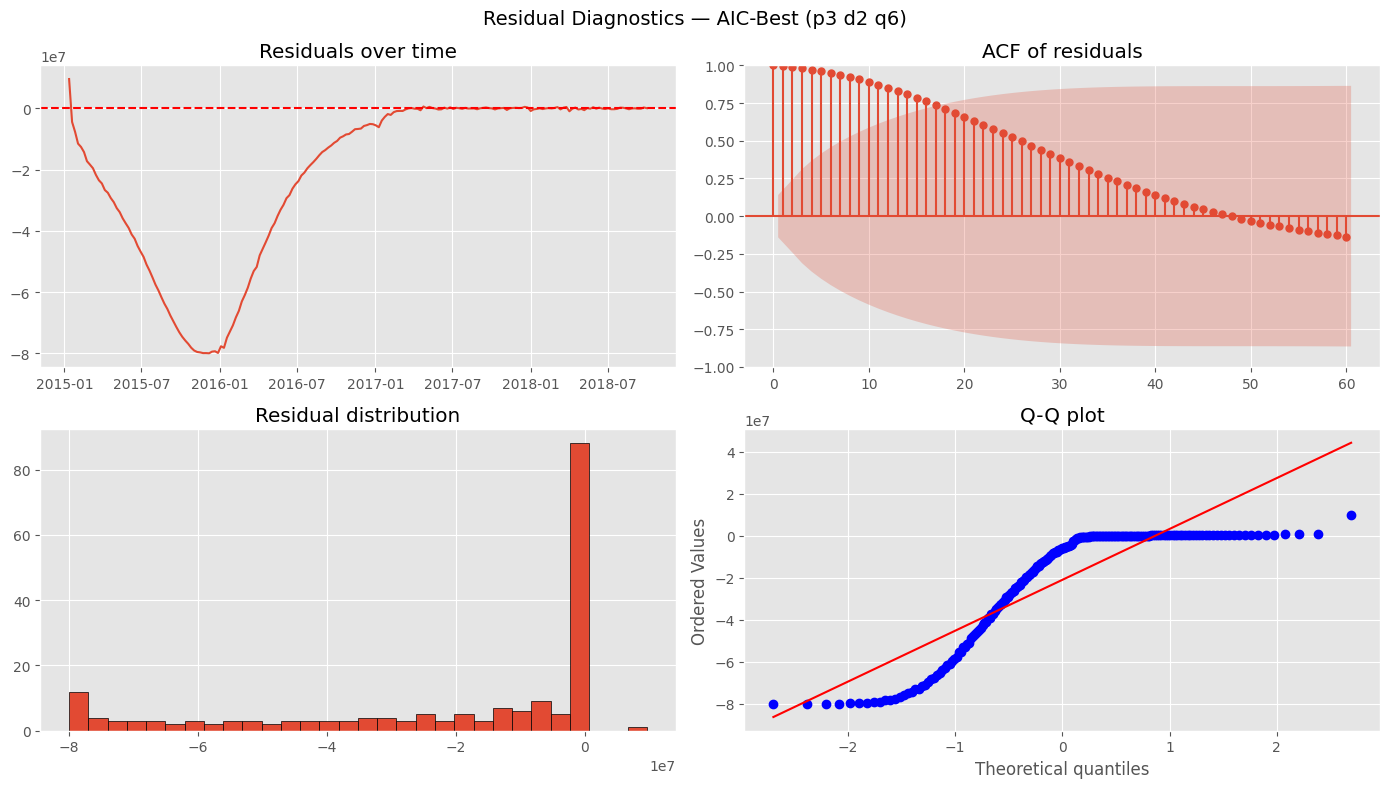


Ljung-Box test — AIC-Best (p3 d2 q6):
        lb_stat  lb_pvalue
10  1829.912154        0.0
20  3106.794100        0.0
30  3705.718328        0.0
(p-value > 0.05 at each lag = no significant leftover autocorrelation = good fit)

Residual mean: -21084460.80 | Residual std: 27162128.42
AIC: 2315.37 | BIC: 2344.25


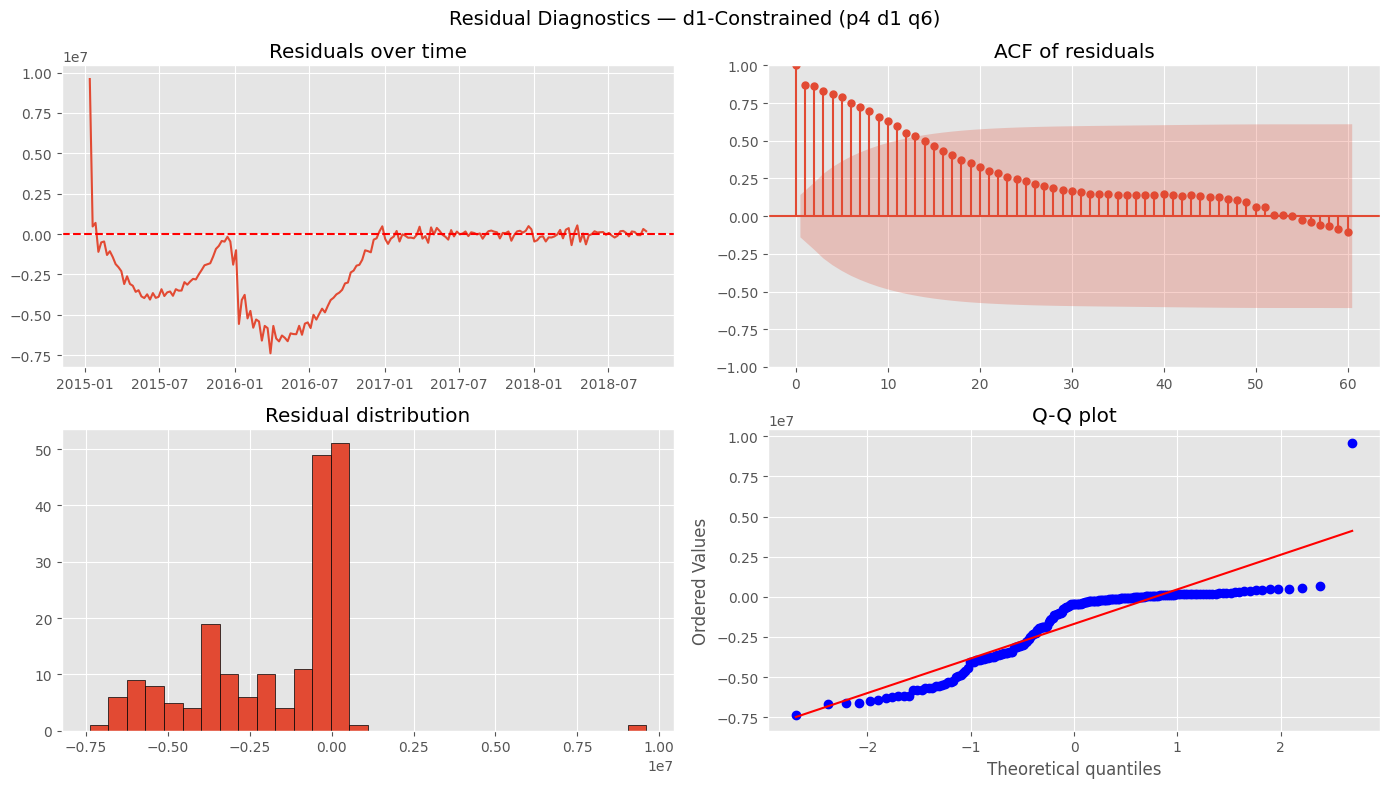


Ljung-Box test — d1-Constrained (p4 d1 q6):
        lb_stat      lb_pvalue
10  1188.228056  4.986007e-249
20  1643.475880   0.000000e+00
30  1762.800090   0.000000e+00
(p-value > 0.05 at each lag = no significant leftover autocorrelation = good fit)

Residual mean: -1688813.61 | Residual std: 2328504.09
AIC: 2327.61 | BIC: 2359.06


In [12]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

def diagnose_residuals(fitted_model, name):
    resid = fitted_model.resid

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'Residual Diagnostics — {name}', fontsize=14)

    # Time plot of residuals
    axes[0, 0].plot(resid)
    axes[0, 0].axhline(0, color='red', linestyle='--')
    axes[0, 0].set_title('Residuals over time')

    # ACF of residuals
    plot_acf(resid.dropna(), lags=60, ax=axes[0, 1])
    axes[0, 1].set_title('ACF of residuals')

    # Histogram of residuals
    axes[1, 0].hist(resid.dropna(), bins=30, edgecolor='black')
    axes[1, 0].set_title('Residual distribution')

    # Q-Q plot
    stats.probplot(resid.dropna(), dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q plot')

    plt.tight_layout()
    plt.savefig(f'residual_diagnostics_{name.replace(" ", "_").replace("=","")}.png', dpi=150)
    plt.show()

    # Ljung-Box test - formal test for residual autocorrelation (lags 10, 20, 30)
    lb_test = acorr_ljungbox(resid.dropna(), lags=[10, 20, 30], return_df=True)
    print(f"\nLjung-Box test — {name}:")
    print(lb_test)
    print("(p-value > 0.05 at each lag = no significant leftover autocorrelation = good fit)")

    print(f"\nResidual mean: {resid.mean():.2f} | Residual std: {resid.std():.2f}")
    print(f"AIC: {fitted_model.aic:.2f} | BIC: {fitted_model.bic:.2f}")

# Diagnose both models
diagnose_residuals(model_aic_best, "AIC-Best (p3 d2 q6)")
diagnose_residuals(model_d1_best, "d1-Constrained (p4 d1 q6)")

## Step 3.4: Forecast the 2-Year Test Horizon with Confidence Intervals

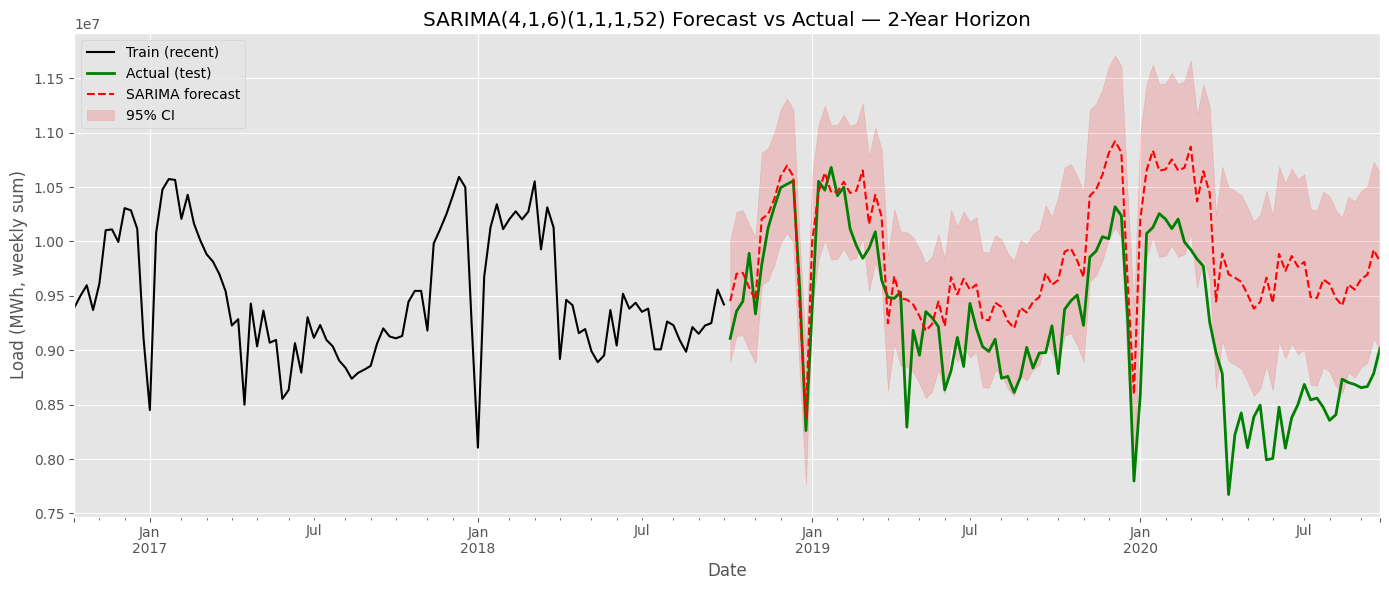


SARIMA Evaluation Metrics:
{'Model': 'SARIMA(4,1,6)(1,1,1,52)', 'RMSE': np.float64(770574.2163221603), 'MAE': 636355.9738267735, 'MAPE (%)': np.float64(7.179229857644355)}

Updated master metrics table:
                  Model          RMSE           MAE  MAPE (%)
         Seasonal Naive 454051.060112 342863.826923  3.862459
                  Drift 727256.958348 620585.440028  6.817314
                   Mean 739221.517876 629533.841174  6.906660
                  Naive 749960.658994 640566.778846  7.071051
SARIMA(4,1,6)(1,1,1,52) 770574.216322 636355.973827  7.179230


In [13]:
# Use the d1-constrained model going forward (justified above)
sarima_final = model_d1_best

# Get forecast object for the test horizon (104 weeks)
forecast_obj = sarima_final.get_forecast(steps=horizon)
sarima_forecast_mean = forecast_obj.predicted_mean
sarima_conf_int = forecast_obj.conf_int(alpha=0.05)  # 95% CI

sarima_forecast_mean.index = test.index
sarima_conf_int.index = test.index

# Plot forecast vs actual with confidence interval
fig, ax = plt.subplots(figsize=(14, 6))
train['load'].tail(104).plot(ax=ax, label='Train (recent)', color='black')
test['load'].plot(ax=ax, label='Actual (test)', color='green', linewidth=2)
sarima_forecast_mean.plot(ax=ax, label='SARIMA forecast', color='red', linestyle='--')
ax.fill_between(sarima_conf_int.index,
                 sarima_conf_int.iloc[:, 0],
                 sarima_conf_int.iloc[:, 1],
                 color='red', alpha=0.15, label='95% CI')

ax.set_title('SARIMA(4,1,6)(1,1,1,52) Forecast vs Actual — 2-Year Horizon')
ax.set_ylabel('Load (MWh, weekly sum)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.savefig('sarima_forecast.png', dpi=150)
plt.show()

# Evaluate and append to master metrics table
sarima_metrics = evaluate_forecast(test['load'], sarima_forecast_mean, 'SARIMA(4,1,6)(1,1,1,52)')
print("\nSARIMA Evaluation Metrics:")
print(sarima_metrics)

metrics_table = pd.concat([metrics_table, pd.DataFrame([sarima_metrics])], ignore_index=True)
metrics_table = metrics_table.sort_values('RMSE').reset_index(drop=True)
print("\nUpdated master metrics table:")
print(metrics_table.to_string(index=False))
metrics_table.to_csv('metrics_table.csv', index=False)

# Part 4: Adding Temperature as an Exogenous Variable (SARIMAX)

## Step 4.1: Retrieve Berlin Temperature Data from Open-Meteo

In [14]:
import requests

# Berlin coordinates
lat, lon = 52.52, 13.41

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2015-01-01",
    "end_date": "2020-09-30",
    "daily": "temperature_2m_mean,temperature_2m_max,temperature_2m_min",
    "timezone": "UTC"
}

print("Requesting Berlin temperature data from Open-Meteo...")
response = requests.get(url, params=params)
response.raise_for_status()
weather_data = response.json()

temp_df = pd.DataFrame(weather_data['daily'])
temp_df['time'] = pd.to_datetime(temp_df['time'])
temp_df = temp_df.set_index('time')

print("Temperature data shape:", temp_df.shape)
print("Date range:", temp_df.index.min(), "to", temp_df.index.max())
print("\nFirst few rows:")
print(temp_df.head())
print("\nMissing values:")
print(temp_df.isna().sum())

# Resample to weekly (mean temperature), aligned to same W-MON convention as load data
temp_weekly = temp_df[['temperature_2m_mean']].resample('W-MON').mean()
temp_weekly = temp_weekly.rename(columns={'temperature_2m_mean': 'temp_mean'})

# Trim to match our trimmed weekly load index (drop any edge weeks not in weekly.index)
temp_weekly = temp_weekly.reindex(weekly.index)

print("\nWeekly temperature shape (aligned to load index):", temp_weekly.shape)
print("Missing values after alignment:", temp_weekly.isna().sum())
print(temp_weekly.head())

Requesting Berlin temperature data from Open-Meteo...
Temperature data shape: (2100, 3)
Date range: 2015-01-01 00:00:00 to 2020-09-30 00:00:00

First few rows:
            temperature_2m_mean  temperature_2m_max  temperature_2m_min
time                                                                   
2015-01-01                  2.6                 4.4                 0.9
2015-01-02                  4.9                 7.5                 1.6
2015-01-03                  3.8                 5.1                 2.9
2015-01-04                  2.8                 4.2                 1.1
2015-01-05                  2.9                 3.7                 1.1

Missing values:
temperature_2m_mean    0
temperature_2m_max     0
temperature_2m_min     0
dtype: int64

Weekly temperature shape (aligned to load index): (299, 1)
Missing values after alignment: temp_mean    299
dtype: int64
                           temp_mean
utc_timestamp                       
2015-01-12 00:00:00+00:00        Na

In [16]:
# Re-fetch a clean weekly temp series from temp_df to avoid any prior state issues
temp_weekly = temp_df[['temperature_2m_mean']].resample('W-MON').mean()
temp_weekly = temp_weekly.rename(columns={'temperature_2m_mean': 'temp_mean'})

print("Is temp_weekly index tz-aware?", temp_weekly.index.tz is not None)

# Only localize if it's naive; otherwise convert
if temp_weekly.index.tz is None:
    temp_weekly.index = temp_weekly.index.tz_localize('UTC')
else:
    temp_weekly.index = temp_weekly.index.tz_convert('UTC')

# Re-align to load's weekly index
temp_weekly = temp_weekly.reindex(weekly.index)

print("\nWeekly temperature shape (aligned to load index):", temp_weekly.shape)
print("Missing values after alignment:", temp_weekly['temp_mean'].isna().sum())
print("\nFirst few rows:")
print(temp_weekly.head())
print("\nLast few rows:")
print(temp_weekly.tail())

Is temp_weekly index tz-aware? False

Weekly temperature shape (aligned to load index): (299, 1)
Missing values after alignment: 0

First few rows:
                           temp_mean
utc_timestamp                       
2015-01-12 00:00:00+00:00   4.228571
2015-01-19 00:00:00+00:00   4.057143
2015-01-26 00:00:00+00:00   0.371429
2015-02-02 00:00:00+00:00   1.200000
2015-02-09 00:00:00+00:00  -0.785714

Last few rows:
                           temp_mean
utc_timestamp                       
2020-08-31 00:00:00+00:00  17.428571
2020-09-07 00:00:00+00:00  15.514286
2020-09-14 00:00:00+00:00  17.414286
2020-09-21 00:00:00+00:00  16.642857
2020-09-28 00:00:00+00:00  14.500000


## Step 4.2: Visualize Load vs. Temperature, Then Fit SARIMAX

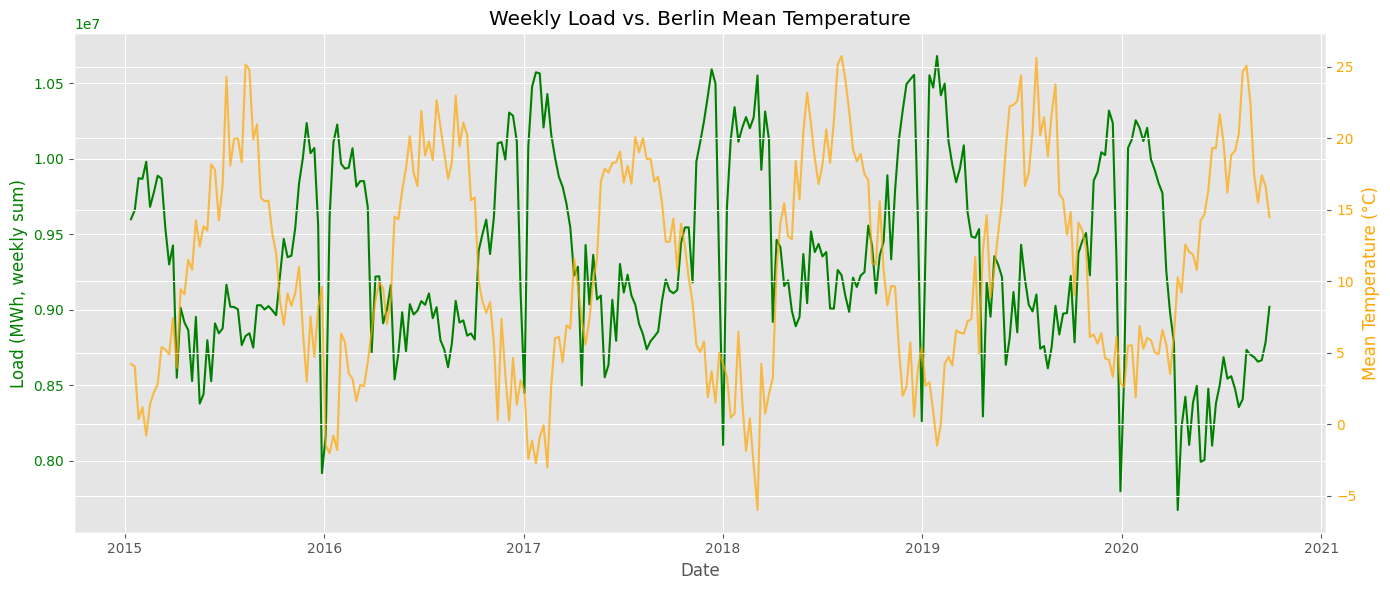

Correlation between load and temperature: -0.649

SARIMAX model fitted.
AIC: 2332.90 | BIC: 2366.77
(Compare to SARIMA without exog — AIC: 2327.61)

Exogenous variable coefficient:
temp_mean   -9487.3446
dtype: float64


In [17]:
# Dual-axis plot: load and temperature over time
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(weekly.index, weekly['load'], color='green', label='Load')
ax1.set_ylabel('Load (MWh, weekly sum)', color='green')
ax1.tick_params(axis='y', labelcolor='green')

ax2 = ax1.twinx()
ax2.plot(temp_weekly.index, temp_weekly['temp_mean'], color='orange', alpha=0.7, label='Temp')
ax2.set_ylabel('Mean Temperature (°C)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

ax1.set_title('Weekly Load vs. Berlin Mean Temperature')
ax1.set_xlabel('Date')
plt.tight_layout()
plt.savefig('load_vs_temperature.png', dpi=150)
plt.show()

# Correlation check
correlation = weekly['load'].corr(temp_weekly['temp_mean'])
print(f"Correlation between load and temperature: {correlation:.3f}")

# --- Fit SARIMAX with temperature as exogenous variable ---
# NOTE: this uses OBSERVED (actual, already-known) future temperature in the test set.
# This makes it an EXPLANATORY/CONDITIONAL forecast, not a true operational forecast,
# since real-world forecasting would only have access to a weather FORECAST, not observed data.

exog_train = temp_weekly.loc[train.index]
exog_test = temp_weekly.loc[test.index]

order = (int(best_d1['p']), int(best_d1['d']), int(best_d1['q']))
seasonal_order = (int(best_d1['P']), int(best_d1['D']), int(best_d1['Q']), 52)

sarimax_model = SARIMAX(
    train['load'],
    exog=exog_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print("\nSARIMAX model fitted.")
print(f"AIC: {sarimax_model.aic:.2f} | BIC: {sarimax_model.bic:.2f}")
print(f"(Compare to SARIMA without exog — AIC: {model_d1_best.aic:.2f})")

# Coefficient on the exogenous variable
print("\nExogenous variable coefficient:")
print(sarimax_model.params.filter(like='temp_mean'))

## Step 4.3: Forecast with SARIMAX (Conditional Forecast) and Evaluate

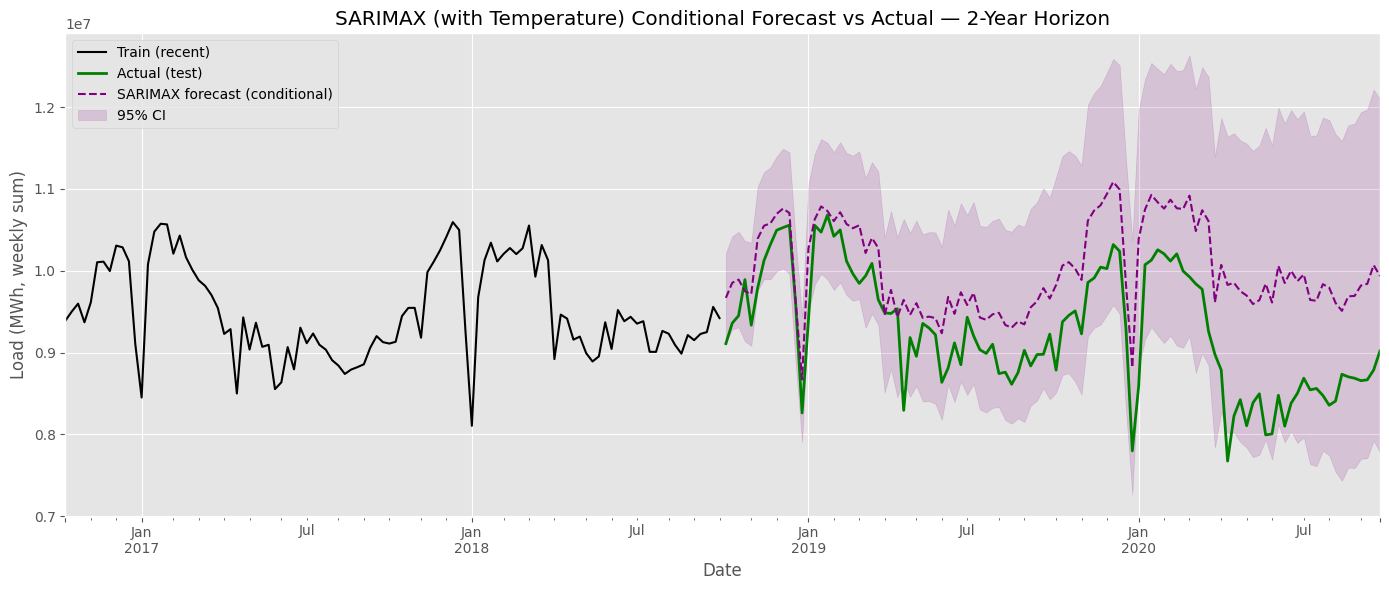


SARIMAX Evaluation Metrics:
{'Model': 'SARIMAX (+Temperature, conditional)', 'RMSE': np.float64(883644.4101428433), 'MAE': 749962.1221032222, 'MAPE (%)': np.float64(8.433957160738135)}

Updated master metrics table:
                              Model          RMSE           MAE  MAPE (%)
                     Seasonal Naive 454051.060112 342863.826923  3.862459
                              Drift 727256.958348 620585.440028  6.817314
                               Mean 739221.517876 629533.841174  6.906660
                              Naive 749960.658994 640566.778846  7.071051
            SARIMA(4,1,6)(1,1,1,52) 770574.216322 636355.973827  7.179230
SARIMAX (+Temperature, conditional) 883644.410143 749962.122103  8.433957


In [18]:
# Reminder: this is a CONDITIONAL/EXPLANATORY forecast since it uses OBSERVED future
# temperature, not a real weather forecast - stated explicitly per the brief's requirement.

sarimax_forecast_obj = sarimax_model.get_forecast(steps=horizon, exog=exog_test)
sarimax_forecast_mean = sarimax_forecast_obj.predicted_mean
sarimax_conf_int = sarimax_forecast_obj.conf_int(alpha=0.05)

sarimax_forecast_mean.index = test.index
sarimax_conf_int.index = test.index

# Plot forecast vs actual
fig, ax = plt.subplots(figsize=(14, 6))
train['load'].tail(104).plot(ax=ax, label='Train (recent)', color='black')
test['load'].plot(ax=ax, label='Actual (test)', color='green', linewidth=2)
sarimax_forecast_mean.plot(ax=ax, label='SARIMAX forecast (conditional)', color='purple', linestyle='--')
ax.fill_between(sarimax_conf_int.index,
                 sarimax_conf_int.iloc[:, 0],
                 sarimax_conf_int.iloc[:, 1],
                 color='purple', alpha=0.15, label='95% CI')

ax.set_title('SARIMAX (with Temperature) Conditional Forecast vs Actual — 2-Year Horizon')
ax.set_ylabel('Load (MWh, weekly sum)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.savefig('sarimax_forecast.png', dpi=150)
plt.show()

# Evaluate and append to master metrics table
sarimax_metrics = evaluate_forecast(test['load'], sarimax_forecast_mean, 'SARIMAX (+Temperature, conditional)')
print("\nSARIMAX Evaluation Metrics:")
print(sarimax_metrics)

metrics_table = pd.concat([metrics_table, pd.DataFrame([sarimax_metrics])], ignore_index=True)
metrics_table = metrics_table.sort_values('RMSE').reset_index(drop=True)
print("\nUpdated master metrics table:")
print(metrics_table.to_string(index=False))
metrics_table.to_csv('metrics_table.csv', index=False)

# Part 5: Feature-Based Regression ModelStep

## 5.1: Feature Engineering for Random Forest / Gradient Boosting

In [19]:
# Build a combined dataframe: load + temperature
feat_df = weekly.copy()
feat_df['temp_mean'] = temp_weekly['temp_mean']

# Lag features (load) - using only PAST values, no leakage
feat_df['load_lag1'] = feat_df['load'].shift(1)
feat_df['load_lag2'] = feat_df['load'].shift(2)
feat_df['load_lag52'] = feat_df['load'].shift(52)  # same week last year

# Rolling statistics (past-only, using shift(1) before rolling to avoid including current row)
feat_df['load_roll4_mean'] = feat_df['load'].shift(1).rolling(window=4).mean()
feat_df['load_roll4_std'] = feat_df['load'].shift(1).rolling(window=4).std()

# Calendar features (these ARE known in advance - no leakage risk)
feat_df['week_of_year'] = feat_df.index.isocalendar().week.astype(int)
feat_df['month'] = feat_df.index.month
feat_df['year'] = feat_df.index.year

# Temperature: current-week temp is used here (same conditional-forecast caveat as Part 4 applies)
# For a true operational model, this would need to come from a weather FORECAST, not observed data

print("Feature dataframe shape (before dropping NaNs from lags):", feat_df.shape)
print("\nMissing values per column:")
print(feat_df.isna().sum())

# Drop rows with NaN (from the lag52 feature mainly - loses first 52 weeks)
feat_df_clean = feat_df.dropna()
print("\nShape after dropping NaN rows:", feat_df_clean.shape)
print("Date range after cleaning:", feat_df_clean.index.min(), "to", feat_df_clean.index.max())

feat_df_clean.head()

Feature dataframe shape (before dropping NaNs from lags): (299, 10)

Missing values per column:
load                0
temp_mean           0
load_lag1           1
load_lag2           2
load_lag52         52
load_roll4_mean     4
load_roll4_std      4
week_of_year        0
month               0
year                0
dtype: int64

Shape after dropping NaN rows: (247, 10)
Date range after cleaning: 2016-01-11 00:00:00+00:00 to 2020-09-28 00:00:00+00:00


,load,temp_mean,load_lag1,load_lag2,load_lag52,load_roll4_mean,load_roll4_std,week_of_year,month,year
utc_timestamp,,,,,,,,,,
2016-01-11 00:00:00+00:00,9619210.0,-2.014286,8171998.0,7918378.0,9600112.0,8930966.50,1.048972e+06,2,1,2016
2016-01-18 00:00:00+00:00,10109187.0,-0.771429,9619210.0,8171998.0,9660382.0,8817735.00,8.983597e+05,3,1,2016
2016-01-25 00:00:00+00:00,10227697.0,-1.800000,10109187.0,9619210.0,9872606.0,8954693.25,1.074089e+06,4,1,2016
2016-02-01 00:00:00+00:00,9967733.0,6.357143,10227697.0,10109187.0,9867486.0,9532023.00,9.441663e+05,5,2,2016
2016-02-08 00:00:00+00:00,9935483.0,5.757143,9967733.0,10227697.0,9981378.0,9980956.75,2.635396e+05,6,2,2016


## Step 5.2: Train/Test Split and Random Forest Training

Train shape: (143, 10) | range: 2016-01-11 00:00:00+00:00 to 2018-10-01 00:00:00+00:00
Test shape: (104, 10) | range: 2018-10-08 00:00:00+00:00 to 2020-09-28 00:00:00+00:00

Feature importances:
load_lag52         0.782399
load_lag1          0.069398
temp_mean          0.042831
week_of_year       0.027529
load_lag2          0.020866
load_roll4_mean    0.018057
load_roll4_std     0.014135
month              0.014080
year               0.010705
dtype: float64


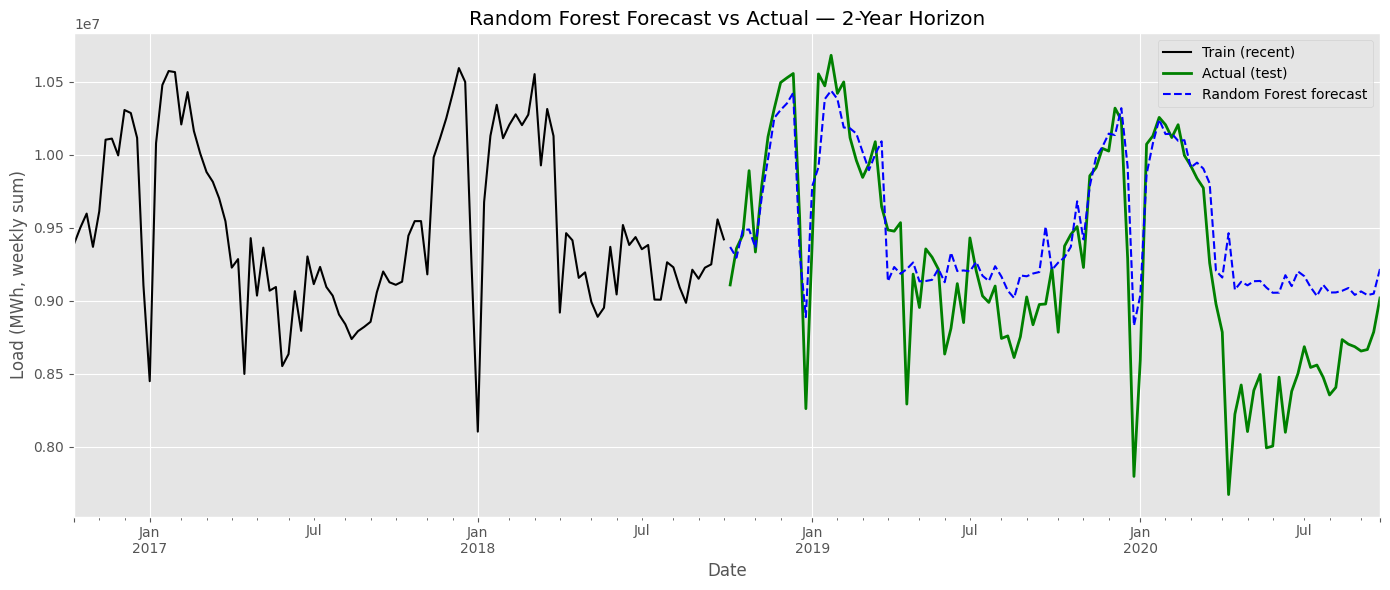


Random Forest Evaluation Metrics:
{'Model': 'Random Forest', 'RMSE': np.float64(456014.10165223), 'MAE': 336857.0940082288, 'MAPE (%)': np.float64(3.864569729515422)}

Updated master metrics table:
                              Model          RMSE           MAE  MAPE (%)
                     Seasonal Naive 454051.060112 342863.826923  3.862459
                      Random Forest 456014.101652 336857.094008  3.864570
                              Drift 727256.958348 620585.440028  6.817314
                               Mean 739221.517876 629533.841174  6.906660
                              Naive 749960.658994 640566.778846  7.071051
            SARIMA(4,1,6)(1,1,1,52) 770574.216322 636355.973827  7.179230
SARIMAX (+Temperature, conditional) 883644.410143 749962.122103  8.433957


In [20]:
from sklearn.ensemble import RandomForestRegressor

feature_cols = ['temp_mean', 'load_lag1', 'load_lag2', 'load_lag52',
                 'load_roll4_mean', 'load_roll4_std', 'week_of_year', 'month', 'year']

# Split: last 104 weeks = test (same horizon as before)
train_feat = feat_df_clean.iloc[:-horizon].copy()
test_feat = feat_df_clean.iloc[-horizon:].copy()

print("Train shape:", train_feat.shape, "| range:", train_feat.index.min(), "to", train_feat.index.max())
print("Test shape:", test_feat.shape, "| range:", test_feat.index.min(), "to", test_feat.index.max())

X_train, y_train = train_feat[feature_cols], train_feat['load']
X_test, y_test = test_feat[feature_cols], test_feat['load']

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = pd.Series(rf_model.predict(X_test), index=test_feat.index)

# Feature importances
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importances:")
print(importances)

# Plot forecast vs actual
fig, ax = plt.subplots(figsize=(14, 6))
train_feat['load'].tail(104).plot(ax=ax, label='Train (recent)', color='black')
test_feat['load'].plot(ax=ax, label='Actual (test)', color='green', linewidth=2)
rf_pred.plot(ax=ax, label='Random Forest forecast', color='blue', linestyle='--')
ax.set_title('Random Forest Forecast vs Actual — 2-Year Horizon')
ax.set_ylabel('Load (MWh, weekly sum)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.savefig('rf_forecast.png', dpi=150)
plt.show()

# Evaluate and append to metrics table
rf_metrics = evaluate_forecast(test_feat['load'], rf_pred, 'Random Forest')
print("\nRandom Forest Evaluation Metrics:")
print(rf_metrics)

metrics_table = pd.concat([metrics_table, pd.DataFrame([rf_metrics])], ignore_index=True)
metrics_table = metrics_table.sort_values('RMSE').reset_index(drop=True)
print("\nUpdated master metrics table:")
print(metrics_table.to_string(index=False))
metrics_table.to_csv('metrics_table.csv', index=False)

# Part 6: LSTM on Hourly Data

## Step 6.1: Prepare Hourly Data for LSTM (Scaling + Sequence Windows)

In [21]:
from sklearn.preprocessing import MinMaxScaler

# Use the clean hourly series from Part 1
hourly_load = hourly[['load']].copy()
print("Hourly data shape:", hourly_load.shape)
print("Range:", hourly_load.index.min(), "to", hourly_load.index.max())

# 2-year test horizon in hours
hourly_horizon = 24 * 7 * 104  # 104 weeks in hours = 17,472 hours
print(f"\nHourly test horizon: {hourly_horizon} hours (~{hourly_horizon/24/365.25:.2f} years)")

train_hourly = hourly_load.iloc[:-hourly_horizon].copy()
test_hourly = hourly_load.iloc[-hourly_horizon:].copy()

print("Train hourly shape:", train_hourly.shape, "| range:", train_hourly.index.min(), "to", train_hourly.index.max())
print("Test hourly shape:", test_hourly.shape, "| range:", test_hourly.index.min(), "to", test_hourly.index.max())

# Scale using ONLY training data statistics (avoid leakage)
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_hourly[['load']])
test_scaled = scaler.transform(test_hourly[['load']])

print("\nScaler fitted on train only. Train min/max:", train_hourly['load'].min(), train_hourly['load'].max())

# Create sliding window sequences: use past 168 hours (1 week) to predict next hour
window_size = 168

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train_lstm, y_train_lstm = create_sequences(train_scaled, window_size)

# For test, we need the last `window_size` points of train prepended, so first test predictions have context
combined_scaled = np.concatenate([train_scaled[-window_size:], test_scaled])
X_test_lstm, y_test_lstm = create_sequences(combined_scaled, window_size)

# Reshape for LSTM: [samples, timesteps, features]
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

print("\nX_train_lstm shape:", X_train_lstm.shape)
print("y_train_lstm shape:", y_train_lstm.shape)
print("X_test_lstm shape:", X_test_lstm.shape)
print("y_test_lstm shape:", y_test_lstm.shape)

Hourly data shape: (50400, 1)
Range: 2015-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00

Hourly test horizon: 17472 hours (~1.99 years)
Train hourly shape: (32928, 1) | range: 2015-01-01 00:00:00+00:00 to 2018-10-03 23:00:00+00:00
Test hourly shape: (17472, 1) | range: 2018-10-04 00:00:00+00:00 to 2020-09-30 23:00:00+00:00

Scaler fitted on train only. Train min/max: 31307.0 77549.0

X_train_lstm shape: (32760, 168, 1)
y_train_lstm shape: (32760,)
X_test_lstm shape: (17472, 168, 1)
y_test_lstm shape: (17472,)


## Step 6.2: Build and Train the LSTM Model

GPU available: []


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 110s 230ms/step - loss: 0.0237 - val_loss: 0.0045
Epoch 2/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 88s 191ms/step - loss: 0.0061 - val_loss: 0.0035
Epoch 3/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 88s 190ms/step - loss: 0.0041 - val_loss: 0.0029
Epoch 4/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 89s 194ms/step - loss: 0.0030 - val_loss: 0.0014
Epoch 5/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 87s 189ms/step - loss: 0.0024 - val_loss: 0.0015
Epoch 6/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 142s 189ms/step - loss: 0.0021 - val_loss: 9.8548e-04
Epoch 7/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 88s 192ms/step - loss: 0.0018 - val_loss: 9.0698e-04
Epoch 8/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 143s 194ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 9/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 87s 189ms/step - loss: 0.0016 - val_loss: 0.0010
Epoch 10/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 144s 194ms/step - loss: 0.0015 - val_loss: 0.0011
Epoch 11/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 89s 192ms/step - loss: 0.0015 - val_loss: 9.0917e-04
Epo

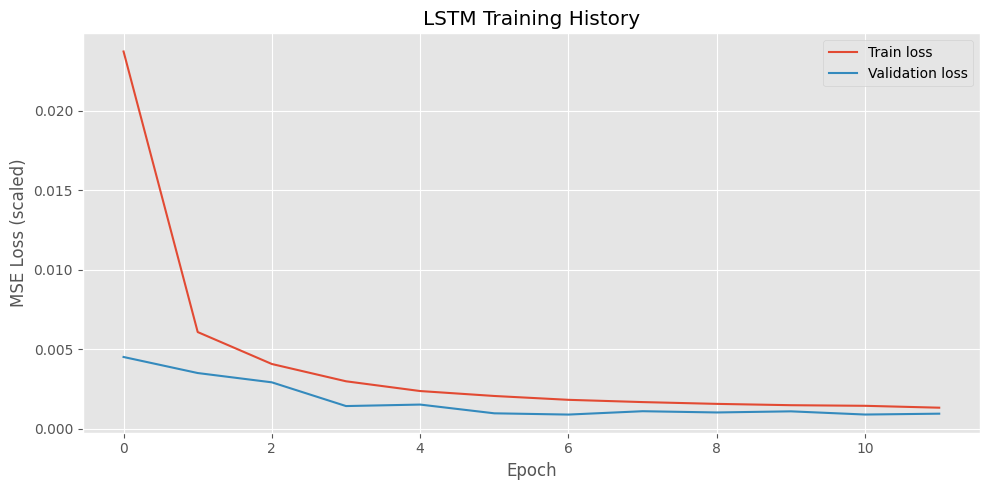


Training stopped after 12 epochs (early stopping patience=5)
Final train loss: 0.001339
Final val loss: 0.000963


In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Check if GPU is available (informational only)
print("GPU available:", tf.config.list_physical_devices('GPU'))

tf.random.set_seed(42)

lstm_model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train (using a validation split carved from the END of training data, i.e. chronologically
# most recent training data - avoids leaking future info the way a random split would)
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=30,
    batch_size=64,
    validation_split=0.1,  # last 10% of X_train_lstm chronologically (Keras does NOT shuffle by default when validation_split is used with non-shuffled fit... but we set shuffle explicitly below to be safe)
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

# Plot training history
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history['loss'], label='Train loss')
ax.plot(history.history['val_loss'], label='Validation loss')
ax.set_title('LSTM Training History')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (scaled)')
ax.legend()
plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150)
plt.show()

print(f"\nTraining stopped after {len(history.history['loss'])} epochs (early stopping patience=5)")
print(f"Final train loss: {history.history['loss'][-1]:.6f}")
print(f"Final val loss: {history.history['val_loss'][-1]:.6f}")

## Step 6.3: Hyperparameter Tuning (Window Size, LSTM Units, Dropout, Learning Rate)

In [23]:
import itertools
import time

# Small, deliberately constrained search space (justified above due to CPU-only compute)
units_options = [(64, 32), (32, 16)]       # (layer1_units, layer2_units)
dropout_options = [0.2, 0.3]
learning_rate_options = [0.001]             # keep fixed at Adam default to limit search size

param_combinations = list(itertools.product(units_options, dropout_options, learning_rate_options))
print(f"Testing {len(param_combinations)} hyperparameter combinations")

tuning_results = []

for i, (units, dropout_rate, lr) in enumerate(param_combinations):
    print(f"\n--- Combination {i+1}/{len(param_combinations)}: units={units}, dropout={dropout_rate}, lr={lr} ---")
    start = time.time()

    tf.random.set_seed(42)
    model = Sequential([
        LSTM(units[0], activation='tanh', return_sequences=True, input_shape=(window_size, 1)),
        Dropout(dropout_rate),
        LSTM(units[1], activation='tanh', return_sequences=False),
        Dropout(dropout_rate),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse')

    early_stop_tune = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    hist = model.fit(
        X_train_lstm, y_train_lstm,
        epochs=15,  # capped lower than final model, just for comparative tuning
        batch_size=64,
        validation_split=0.1,
        shuffle=False,
        callbacks=[early_stop_tune],
        verbose=0
    )

    best_val_loss = min(hist.history['val_loss'])
    elapsed = time.time() - start

    tuning_results.append({
        'units': units,
        'dropout': dropout_rate,
        'lr': lr,
        'best_val_loss': best_val_loss,
        'epochs_run': len(hist.history['loss']),
        'time_sec': elapsed
    })

    print(f"Best val_loss: {best_val_loss:.6f} | Epochs run: {len(hist.history['loss'])} | Time: {elapsed:.1f}s")

# Results table
tuning_df = pd.DataFrame(tuning_results).sort_values('best_val_loss').reset_index(drop=True)
print("\n\nHyperparameter tuning results (sorted by best val_loss):")
print(tuning_df.to_string(index=False))

best_params = tuning_df.iloc[0]
print(f"\nBest combination: units={best_params['units']}, dropout={best_params['dropout']}, lr={best_params['lr']}")

Testing 4 hyperparameter combinations

--- Combination 1/4: units=(64, 32), dropout=0.2, lr=0.001 ---
Best val_loss: 0.001469 | Epochs run: 10 | Time: 1146.6s

--- Combination 2/4: units=(64, 32), dropout=0.3, lr=0.001 ---
Best val_loss: 0.000990 | Epochs run: 9 | Time: 895.7s

--- Combination 3/4: units=(32, 16), dropout=0.2, lr=0.001 ---
Best val_loss: 0.006535 | Epochs run: 5 | Time: 392.7s

--- Combination 4/4: units=(32, 16), dropout=0.3, lr=0.001 ---
Best val_loss: 0.000823 | Epochs run: 15 | Time: 1067.5s


Hyperparameter tuning results (sorted by best val_loss):
   units  dropout    lr  best_val_loss  epochs_run    time_sec
(32, 16)      0.3 0.001       0.000823          15 1067.533839
(64, 32)      0.3 0.001       0.000990           9  895.716933
(64, 32)      0.2 0.001       0.001469          10 1146.627069
(32, 16)      0.2 0.001       0.006535           5  392.701367

Best combination: units=(32, 16), dropout=0.3, lr=0.001


## Step 6.4: Refit Best LSTM, Forecast, Inverse-Scale, Aggregate to Weekly, Evaluate

Refitting final LSTM with best hyperparameters on full training data...
Epoch 1/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 71s 139ms/step - loss: 0.0334 - val_loss: 0.0083
Epoch 2/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 82s 139ms/step - loss: 0.0101 - val_loss: 0.0071
Epoch 3/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 63s 137ms/step - loss: 0.0067 - val_loss: 0.0081
Epoch 4/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 83s 139ms/step - loss: 0.0050 - val_loss: 0.0061
Epoch 5/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 81s 138ms/step - loss: 0.0041 - val_loss: 0.0070
Epoch 6/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 81s 136ms/step - loss: 0.0035 - val_loss: 0.0073
Epoch 7/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 83s 138ms/step - loss: 0.0031 - val_loss: 0.0056
Epoch 8/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 83s 139ms/step - loss: 0.0027 - val_loss: 0.0053
Epoch 9/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 81s 138ms/step - loss: 0.0025 - val_loss: 0.0055
Epoch 10/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 81s 136ms/step - loss: 0.0023 - val_loss: 0.0049
Epoch 11/30
461/461 ━━━━━━━━━━━━━━━━━

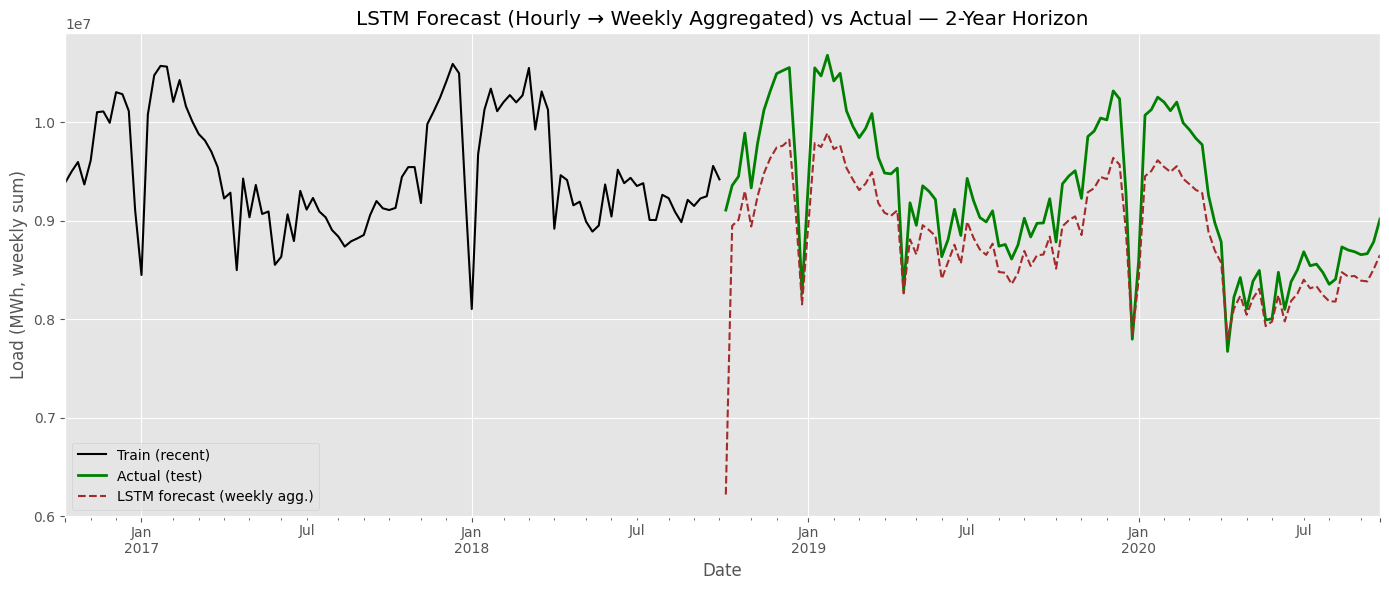


LSTM Evaluation Metrics (weekly-aggregated):
{'Model': 'LSTM (hourly, agg. to weekly)', 'RMSE': np.float64(522267.688086959), 'MAE': 420909.6153846154, 'MAPE (%)': np.float64(4.413821841007145)}

Updated master metrics table:
                              Model          RMSE           MAE  MAPE (%)
                     Seasonal Naive 454051.060112 342863.826923  3.862459
                      Random Forest 456014.101652 336857.094008  3.864570
      LSTM (hourly, agg. to weekly) 522267.688087 420909.615385  4.413822
                              Drift 727256.958348 620585.440028  6.817314
                               Mean 739221.517876 629533.841174  6.906660
                              Naive 749960.658994 640566.778846  7.071051
            SARIMA(4,1,6)(1,1,1,52) 770574.216322 636355.973827  7.179230
SARIMAX (+Temperature, conditional) 883644.410143 749962.122103  8.433957


In [24]:
best_units = (32, 16)
best_dropout = 0.3
best_lr = 0.001

tf.random.set_seed(42)
lstm_final = Sequential([
    LSTM(best_units[0], activation='tanh', return_sequences=True, input_shape=(window_size, 1)),
    Dropout(best_dropout),
    LSTM(best_units[1], activation='tanh', return_sequences=False),
    Dropout(best_dropout),
    Dense(16, activation='relu'),
    Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=best_lr)
lstm_final.compile(optimizer=optimizer, loss='mse')

early_stop_final = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Refitting final LSTM with best hyperparameters on full training data...")
history_final = lstm_final.fit(
    X_train_lstm, y_train_lstm,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stop_final],
    verbose=1
)

print(f"\nFinal model trained for {len(history_final.history['loss'])} epochs")

# --- Predict across the full test horizon ---
print("\nGenerating predictions across test horizon...")
lstm_pred_scaled = lstm_final.predict(X_test_lstm, verbose=1)

# Inverse-transform predictions and true values back to real MWh scale
lstm_pred_real = scaler.inverse_transform(lstm_pred_scaled).flatten()
y_test_real = scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()

# Build a proper indexed series (test_hourly index aligns with y_test_lstm since we
# prepended window_size points from train only for context, not for prediction targets)
lstm_pred_series = pd.Series(lstm_pred_real, index=test_hourly.index[:len(lstm_pred_real)])
actual_hourly_series = pd.Series(y_test_real, index=test_hourly.index[:len(y_test_real)])

print("\nLSTM hourly prediction shape:", lstm_pred_series.shape)
print("Sample predictions vs actual (first 5):")
print(pd.DataFrame({'actual': actual_hourly_series.head(), 'predicted': lstm_pred_series.head()}))

# --- Aggregate hourly predictions and actuals to WEEKLY sums for fair comparison ---
lstm_pred_weekly = lstm_pred_series.resample('W-MON').sum()
actual_weekly_from_hourly = actual_hourly_series.resample('W-MON').sum()

# Align to our existing weekly test index (drop any partial edge weeks)
lstm_pred_weekly = lstm_pred_weekly.reindex(test.index).dropna()
actual_weekly_aligned = actual_weekly_from_hourly.reindex(test.index).dropna()

print("\nWeekly aggregated LSTM forecast shape:", lstm_pred_weekly.shape)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
train['load'].tail(104).plot(ax=ax, label='Train (recent)', color='black')
test['load'].plot(ax=ax, label='Actual (test)', color='green', linewidth=2)
lstm_pred_weekly.plot(ax=ax, label='LSTM forecast (weekly agg.)', color='brown', linestyle='--')
ax.set_title('LSTM Forecast (Hourly → Weekly Aggregated) vs Actual — 2-Year Horizon')
ax.set_ylabel('Load (MWh, weekly sum)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.savefig('lstm_forecast_weekly.png', dpi=150)
plt.show()

# Evaluate on the weekly-aggregated series, matching our master table's convention
lstm_metrics = evaluate_forecast(test['load'].reindex(lstm_pred_weekly.index), lstm_pred_weekly, 'LSTM (hourly, agg. to weekly)')
print("\nLSTM Evaluation Metrics (weekly-aggregated):")
print(lstm_metrics)

metrics_table = pd.concat([metrics_table, pd.DataFrame([lstm_metrics])], ignore_index=True)
metrics_table = metrics_table.sort_values('RMSE').reset_index(drop=True)
print("\nUpdated master metrics table:")
print(metrics_table.to_string(index=False))
metrics_table.to_csv('metrics_table.csv', index=False)

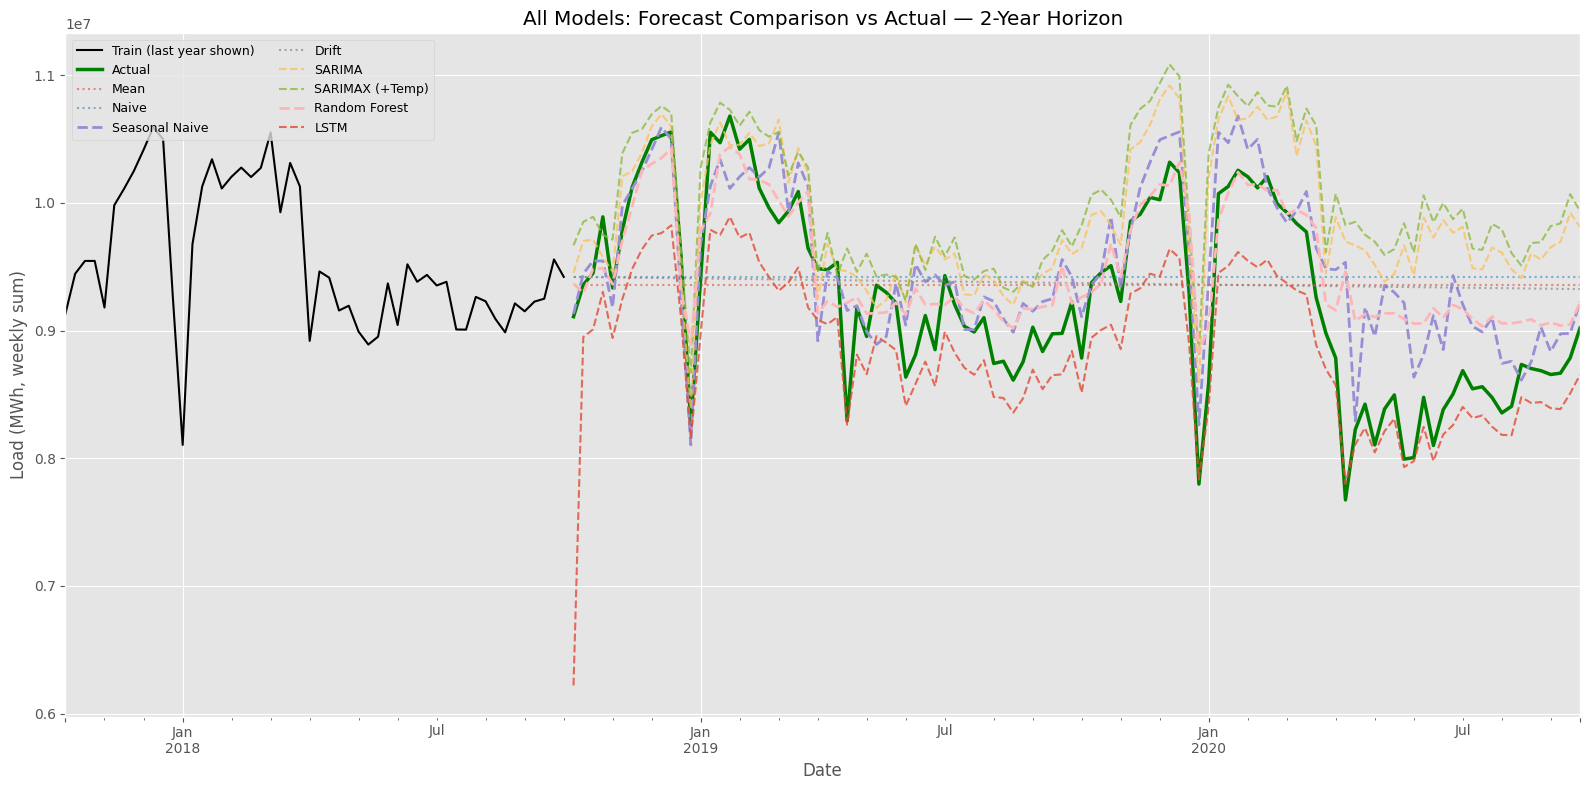

Final metrics table:
                              Model          RMSE           MAE  MAPE (%)
                     Seasonal Naive 454051.060112 342863.826923  3.862459
                      Random Forest 456014.101652 336857.094008  3.864570
      LSTM (hourly, agg. to weekly) 522267.688087 420909.615385  4.413822
                              Drift 727256.958348 620585.440028  6.817314
                               Mean 739221.517876 629533.841174  6.906660
                              Naive 749960.658994 640566.778846  7.071051
            SARIMA(4,1,6)(1,1,1,52) 770574.216322 636355.973827  7.179230
SARIMAX (+Temperature, conditional) 883644.410143 749962.122103  8.433957


In [25]:
# Final combined plot: all models vs actual, on one chart ---

fig, ax = plt.subplots(figsize=(16, 8))

train['load'].tail(52).plot(ax=ax, label='Train (last year shown)', color='black', linewidth=1.5)
test['load'].plot(ax=ax, label='Actual', color='green', linewidth=2.5)

mean_forecast.plot(ax=ax, label='Mean', linestyle=':', alpha=0.6)
naive_forecast.plot(ax=ax, label='Naive', linestyle=':', alpha=0.6)
seasonal_naive_forecast.plot(ax=ax, label='Seasonal Naive', linestyle='--', linewidth=2)
drift_forecast.plot(ax=ax, label='Drift', linestyle=':', alpha=0.6)
sarima_forecast_mean.plot(ax=ax, label='SARIMA', linestyle='--', alpha=0.8)
sarimax_forecast_mean.plot(ax=ax, label='SARIMAX (+Temp)', linestyle='--', alpha=0.8)
rf_pred.plot(ax=ax, label='Random Forest', linestyle='--', linewidth=2)
lstm_pred_weekly.plot(ax=ax, label='LSTM', linestyle='--', alpha=0.8)

ax.set_title('All Models: Forecast Comparison vs Actual — 2-Year Horizon')
ax.set_ylabel('Load (MWh, weekly sum)')
ax.set_xlabel('Date')
ax.legend(loc='upper left', ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150)
plt.show()

print("Final metrics table:")
print(metrics_table.to_string(index=False))
